# Artificial Reef — 4x5 Optimization Example

This notebook is a worked example for a multi-objective optimization
for an artificial-reef design problem. It shows how to:

- Define design variables and bounds
- Specify multiple objective functions and preference mappings
- Build constraints
- Run a Genetic Algorithm (GA) using two (potentially three) aggregation paradigms
- Visualize preference functions and optimization results


## Problem

During the 1990s, the city of Gold Coast experienced significant beach erosion, threatening one of its most valuable assets. The local economy relied heavily on beach-related recreation and surfing tourism, making the loss of beach width a major concern for the city council.

To address the erosion problem, several coastal protection measures were considered, including a multipurpose artificial reef, artificial seaweed, groynes, and offshore breakwaters. Each alternative offered different advantages and disadvantages in terms of cost, coastal protection, environmental impact, aesthetics, and recreational value.

Ultimately, the artificial reef was selected as the preferred solution. In addition to providing coastal protection, it offered several unique benefits: it remained largely invisible from the shoreline, created new habitat for marine life, and generated high-quality surfing waves. These additional functions made the artificial reef an attractive multipurpose solution compared with the more conventional alternatives.

## Importing Required Packages

Below, the required packages are imported. To run this notebook successfully, your environment must include the required dependencies. The virtual environment provided in MUDE, called **`mude-base`**, is sufficient for this purpose.

In addition, several plotting settings are defined, and the local optimisation code is imported. It is important that the provided zip file is extracted in its entirety, as the structure of the directory is required for the imports to work correctly.

The local module `genetic_algorithm_pfm` is imported using a **relative import**, which depends on the directory structure of the project. When the notebook is executed within the provided directory structure, this will work as intended. However, running the notebook outside of this directory will result in the following error: `ModuleNotFoundError: No module named 'genetic_algorithm_pfm'`

In [1]:
# Import libraries
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import pchip_interpolate
from scipy.optimize import minimize 

# Define default plotting parameters
plt.rcParams['font.size'] = '10'  
plt.rcParams['savefig.dpi'] = 300  

# Import local module for genetic algorithm
from genetic_algorithm_pfm import GeneticAlgorithm 

## Design Variables and Bounds

The artificial reef geometry is parameterized using four continuous design variables:

| Variable | Description | Unit | Type |
|----------|-------------|------|------|
| `x1` | Reef length | m | Continuous |
| `x2` | Depth below sea level | m | Continuous |
| `x3` | Reef peel angle | ° | Continuous |
| `x4` | Distance from shore | m | Continuous | 

**Note:** In the code, design variables are defined only by their type (discrete or continuous) and their bounds — *not* by their physical meaning. Before implementing, it is good practice to write down your choice of design variables on paper, including their units and expected ranges. This helps avoid errors and builds physical intuition for the problem.



Each variable is assigned bounds that reflect physically meaningful and feasible values for a real-world reef design. These are defined below.

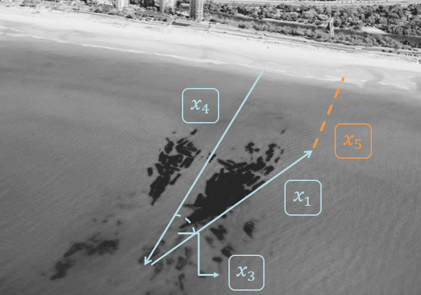

`X_irl` contains a reference design based on a real-world installation, which will later be used for comparison against the optimised solutions. Its design variable values are:

In [2]:
design_variables = (
    ('x1', 'Runway length',              'm'),
    ('x2', 'Runway width',               'm'),
    ('x3', 'True bearing',               '°'),
    ('x4', 'Distance to nearest homes',  'm'),
    ('x5', 'Distance to terminal',       'm'),
    ('x6', 'Material',                   '0=asphalt 1=precast')
)

b1 = [2000, 4000]
b2 = [45, 60]
b3 = [163, 203]
b4 = [500, 4000]
b5 = [760, 5000]
b6 = [0, 1]
bounds = [b1, b2, b3, b4, b5, b6]
#4k is placeholder
X_irl = [3800, 60, 183,750, 5000, 0]
plot_irl = True

## Constraints

Constraints ensure that all solutions remain physically feasible. For this artificial reef model, one physical constraint is considered: **the reef has a minimum distance from the beach**. This constraint, `constraint_1`, is a simple geometric relation corresponding to the distance `x5` shown in the figure above. A constraint function may use as many or as few design variables as necessary.

Each *constraint function* must be expressed as an algebraic expression of the form:

$$g(\mathbf{x}) \leq 0 \quad \text{(feasible)}$$

> **Important:** The constraint function should return only the value of $g(\mathbf{x})$ — do *not* encode the inequality inside the function. The inequality type (`'ineq'`) is specified separately when registering the constraint in `cons`, and the optimiser handles the comparison.

The constraints are registered as follows:

```python
cons = [['ineq', constraint_1], ['ineq', constraint_2]]
```

In [3]:
#constraints
MIN_SEP = 500     # minimum distance to houses we are allowed by law, in m
                       # PLACEHOLDER the LIB does not give a distance, it uses mapped zones
LEN_CODE_F = 3000      # runway longer than this means big planes (A380 etc) so needs full width
                       # 3000 m is the A380 takeoff field length at MTOW
W_CODE_F = 60          # required width in m for those big planes, ICAO Annex 14 Table 3-1

# Parallel runway geometry
SEP_PARALLEL_MIN = 760   # m, below this gap parallel runways are not independent (Doc 4444)
GAP_REF = 2000           # m, current lateral gap to the Zwanenburgbaan, PLACEHOLDER measure this
GAP_TRADE = 1.0          # m of lateral gap lost per m moved toward the terminal
                         # SIMPLIFICATION we use distance to terminal as a proxy for distance
                         # to the neighbouring runway, since the terminal side is also where
                         # the other runways are
D_TERM0 = 5000         # m, current distance to terminal       # m, current distance to terminal
LEN_AVAILABLE = 4400   # m of avaliable length at base condition
LEN_TRADE = 1.0        # m of usable length lost per m moved toward the terminal
                       # PLACEHOLDER set to 1 to 1 for now, the real number is probably higher
   # Construction cost
COST_ASPHALT = 120   # euros per m2, PLACEHOLDER
COST_PRECAST = 260   # euros per m2, higher because precast construction cost is high (Kim and Kim)                   


def constraint_1(variables):
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]
    x5 = variables[:, 4]
    x6 = variables[:, 5]

    return np.where(x1 > LEN_CODE_F, W_CODE_F - x2, -1.0)


def constraint_2(variables):
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]
    x5 = variables[:, 4]
    x6 = variables[:, 5]

    return MIN_SEP - x4


def constraint_3(variables):
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]
    x5 = variables[:, 4]
    x6 = variables[:, 5]

    # the runway has to fit in the corridor, moving toward the terminal makes it shorter
    moved = D_TERM0 - x5
    return x1 - (LEN_AVAILABLE - LEN_TRADE * moved)


cons = [['ineq', constraint_1], ['ineq', constraint_2], ['ineq', constraint_3]]

## Objective Functions

This model optimises five objectives, each representing a different stakeholder identified during the preceding stakeholder analysis. The table below summarises which objective was chosen to represent each stakeholder.

| Stakeholder | Objective | Unit |
|-------------|-----------|------|
| City council | Construction cost | $ |
| Surfing community | Ride length | m |
| Research community | Sediment trapping | m³/yr |
| Local community | Safety | accidents/yr |
| Tourism | Economic growth | $ |

Each objective is then expressed as a function of the design variables. Where needed, physical constants are introduced to make the units consistent — reasonable estimates are sufficient.

In [4]:
# Define objective functions

# Wake turbulence separation minima, ICAO PANS-ATM Doc 4444
SEP_MEDIUM = 2.5    # NM, no wake minimum between mediums, falls back to surveillance minimum
SEP_HEAVY  = 5.0    # NM, medium behind heavy, typical mixed fleet case
SEP_SUPER  = 7.0    # NM, medium behind super (A380), worst realistic commercial case
SEP_LONG   = SEP_HEAVY   # switch to SEP_SUPER for the conservative case

# Takeoff field lengths at MTOW, decide which aircraft the runway can take
LEN_MEDIUM_ONLY = 2240  # m, below this mostly narrowbodies only
LEN_ALL_HEAVY   = 3322   # m, above this the heaviest widebodies fit (B777-300ER)

# Paving rates
MAT_DAYS_ASPHALT = 0.0006  # days per m2, from Aalsmeerbaan 153000 m2 in 91 days
MAT_DAYS_PRECAST = 0.0003  # days per m2, slabs are cast in a factory in parallel with site work

# Current Polderbaan
LEN_REF = 3800       # current runway length in m
WID_REF = 60         # current runway width in m
BEAR_REF = 183       # current runway bearing in deg
MOV_REF = 147600     # current movements per year, 30% of 477000 airport total


def objective_function_1(x1, x2, x3, x4, x5, x6):
    """
    Capacity function for Schiphol. Driven by separation minima. Independence from
    the neighbouring runway is lost either by turning past 15 deg or by moving close
    enough that the lateral gap drops below 760 m.

    :return: float of yearly aircraft movements.
    """
    cons1 = 140     # kt, typical approach speed
    cons2 = 5271   # hours per year the runway runs at capacity found by dividing the yearly movement by hours to be calibrated
    cons3 = 0.70    # capacity left when the runway is no longer independent

    heavy_share = np.clip((x1 - LEN_MEDIUM_ONLY) / (LEN_ALL_HEAVY - LEN_MEDIUM_ONLY), 0, 1)
    sep = SEP_MEDIUM + heavy_share * (SEP_LONG - SEP_MEDIUM)

    gap = GAP_REF - GAP_TRADE * (D_TERM0 - x5)
    parallel = np.where((np.abs(x3 - BEAR_REF) <= 15) & (gap >= SEP_PARALLEL_MIN), 1.0, cons3)

    return cons2 * (cons1 / sep) * parallel

def objective_function_2(x1, x2, x3, x4, x5, x6):
    """
    Capacity function for ATC. Same number as objective 1, the difference
    is in the preference curve, ATC wants it to stay the same.

    :return: float of yearly aircraft movements.
    """
    return objective_function_1(x1, x2, x3, x4, x5, x6)


def objective_function_3(x1, x2, x3, x4, x5, x6):
    """
    Noise function. Sound level at the nearest houses.

    Form is the aircraft noise propagation equation from arXiv:0804.4135
    L_P = L_ref - 20 log10 R + d_atm + d_ground + d_V + d_D + d_f
    where 20 log10 R is the geometric divergence. The source level L_ref and
    all the correction terms are lumped into cons5, which is fitted so the
    current runway gives 56 dB(A) Lden, mid range of the 52 to 60 dB(A) Lden
    limit values at the 35 LVB enforcement points (CDV 2006 section 3.1).

    :return: float of dB(A) Lden at the nearest houses.
    """
    cons5 = 113.5   # dB, calibration constant, see docstring

    return cons5 - 20 * np.log10(x4)

def objective_function_4(x1, x2, x3, x4, x5, x6):
    """
    Air pollution function. More flights and longer taxiing means more emissions.

    :return: float of tonnes of CO2 per year.
    """
    cons8 = 0.0152  # tonnes CO2 per taxi minute, from 4.8 kg fuel/min at idle thrust

    movements = objective_function_1(x1, x2, x3, x4, x5, x6)
    taxi_min = objective_function_8(x1, x2, x3, x4, x5, x6)

    return movements * taxi_min * cons8


def objective_function_5(x1, x2, x3, x4, x5, x6):
    """
    Construction duration function.

    :return: float of construction time in days.
    """
   

    precast = np.round(x6)
    days_m2 = MAT_DAYS_ASPHALT + precast * (MAT_DAYS_PRECAST - MAT_DAYS_ASPHALT)

    return  x1 * x2 * days_m2


def objective_function_6(x1, x2, x3, x4, x5, x6):
    """
    Project size function. Bigger job means more revenue for contractors.

    :return: float of paved area in m2.
    """
    return x1 * x2

def objective_function_7(x1, x2, x3, x4, x5, x6):
    """
    Capacity function for Airlines. Same number as objective 1.

    :return: float of yearly aircraft movements.
    """
    return objective_function_1(x1, x2, x3, x4, x5, x6)


def objective_function_8(x1, x2, x3, x4, x5, x6):
    """
    Taxi time function. Calibrated so the current Polderbaan gives the
    reported ~15 minutes.

    :return: float of one way taxi time in minutes.
    """
    cons10 = 32     # taxi speed in km/h calibrated to give 15 min at 500 m
    cons11 = 5.6      # fixed minutes for pushback and lining up

    return (x5 / 1000) / cons10 * 60 + cons11
def objective_function_9(x1, x2, x3, x4, x5, x6):
    """
    Construction cost for Schiphol, who pays for the runway. Precast builds
    faster but costs more per m2.

    :return: float of cost in million euros.
    """
    precast = np.round(x6)
    cost_m2 = COST_ASPHALT + precast * (COST_PRECAST - COST_ASPHALT)

    return x1 * x2 * cost_m2 / 1e6

# Define the list of objectives with their corresponding names and units and stakeholders for later use in plotting and analysis
objectives = [
    (objective_function_1, "Capacity (Schiphol)",      "movements/yr",  "Schiphol"),
    (objective_function_2, "Capacity (ATC)",           "movements/yr",  "Air Traffic Control"),
    (objective_function_3, "Noise at nearest houses", "dB(A) Lden",    "Residents"),
    (objective_function_4, "Air pollution",            "tonnes CO2/yr", "Residents"),
    (objective_function_5, "Construction duration",    "days",          "Contractors"),
    (objective_function_6, "Project size",             "m2",            "Contractors"),
    (objective_function_7, "Capacity (Airlines)",      "movements/yr",  "Airlines"),
    (objective_function_8, "Taxi time",                "min",           "Airlines"),
    (objective_function_9, "Construction cost",        "M euro",        "Schiphol")
]

While developing the objectuve functions, it can be helpful to investigate their behavior. Here the attainable minimum and maximum of each objective is computed. These ranges serve as a sanity check — if the values are physically unreasonable, revisit the formulation and its constants. The ranges also define the interval over which each objective is rated in the preference functions.

Optionally, the objective functions can be visualised using `matplotlib` or [Desmos](https://www.desmos.com/calculator) to further inspect their behaviour.

To compute the minimum and maximum values we can use the `minimize` command, which is part of the SciPy package. For more infomration see: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html.

In [5]:
# Finding min and max for each objective using a grid search over the bounds.
# scipy's minimize is unreliable here because np.abs and np.round make the
# objectives non-differentiable, so it gets stuck at the starting point.
import itertools

objective_minmax = {}
grids = [np.linspace(b[0], b[1], 9) for b in bounds]
pts = np.array(list(itertools.product(*grids)))

for idx, (obj_func, name, unit, stakeholder) in enumerate(objectives):
    vals = obj_func(pts[:, 0], pts[:, 1], pts[:, 2], pts[:, 3], pts[:, 4], pts[:, 5])
    min_val, max_val = vals.min(), vals.max()

    objective_minmax[name] = min_val, max_val
    print(f"  Objective {idx+1}  :    min = {min_val:>15,.1f}  {unit:<14}    max = {max_val:>15,.1f}  {unit}")

  Objective 1  :    min =       103,311.6  movements/yr      max =       295,176.0  movements/yr
  Objective 2  :    min =       103,311.6  movements/yr      max =       295,176.0  movements/yr
  Objective 3  :    min =            41.5  dB(A) Lden        max =            59.5  dB(A) Lden
  Objective 4  :    min =        11,031.6  tonnes CO2/yr     max =        67,188.0  tonnes CO2/yr
  Objective 5  :    min =            27.0  days              max =           144.0  days
  Objective 6  :    min =        90,000.0  m2                max =       240,000.0  m2
  Objective 7  :    min =       103,311.6  movements/yr      max =       295,176.0  movements/yr
  Objective 8  :    min =             7.0  min               max =            15.0  min
  Objective 9  :    min =            10.8  M euro            max =            62.4  M euro


## Weights

When combining multiple objectives into a single score, each objective is assigned a weight **$w_i$** reflecting its relative importance. All weights must sum to one:

$$\sum_{i=1}^{5} w_i = 1$$

| Weight | Stakeholder | Objective |
|--------|-------------|-----------|
| $w_1$ | City council | Cost |
| $w_2$ | Surfing community | Ride length |
| $w_3$ | Research community | Sediment trapping |
| $w_4$ | Local community | Safety |
| $w_5$ | Tourism | Economic growth |

In this model, all weights are initialised equally ($w_i = \frac{1}{5} = 0.2$) for simplicity.

In [6]:
#                  schiphol  atc   noise  air  duration  size  a-cap  taxi  cost
weights_before =   [0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.111, 0.112]
weights_after =    [0.25,  0.25,  0.06,  0.04,  0.025, 0.025, 0.12,  0.08,  0.15]

weights = weights_before

assert np.isclose(sum(weights), 1.0), f"Weights must sum to 1, got {sum(weights)}"

## Preference Curves and Preference Functions

Each objective value is mapped to a preference score between 0 and 100 using a *preference curve*, which represents a stakeholder's preference towards their objective. This allows objectives with different units and scales to be compared and combined, where 0 indicates the least desirable outcome and 100 the most desirable.

The curves are defined by a set of control points interpolated using `pchip_interpolate` from the SciPy package, which produces smooth curves that pass exactly through each point. Only the shape of the matters — so no analytical function is needed. Creating preference curves using interpolation is a convenient and flexible approach. Start simple and increase complexity only if necessary; aim to capture the essential behaviour with as few points as possible. The prefence curves are then plotted.

For this reef model, four objectives are rated linearly in the technical cycle. The exception is sediment trapping (objective 3), which follows a non-linear preference: too little trapping fails to widen the beach, but too much blocks sediment from reaching downstream beaches — so an intermediate value is preferred.

Each preference curve is then combined with its corresponding objective function to form a *preference function*, which maps design variables directly to a preference score.

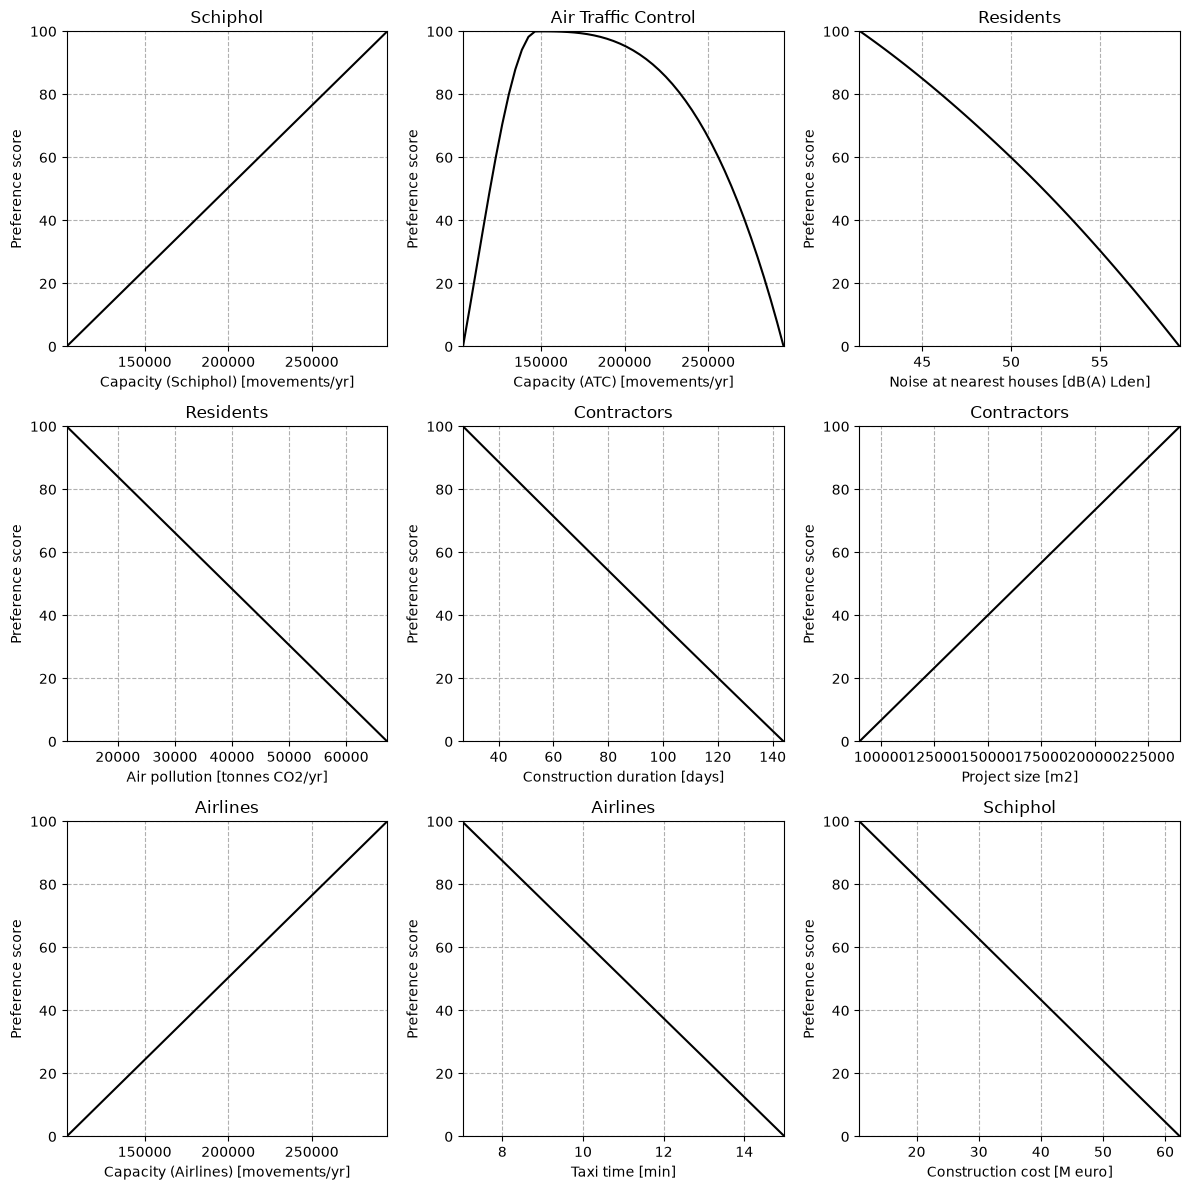

In [8]:
# Define preferences
prefs_before = [[[103312, 199244, 295176],      [0, 50, 100]],      # capacity schiphol, more is better
                [[103312, 147000 , 295176],      [0, 100, 0]],       # capacity atc, peaks at the current level
                [[41.5, 50, 59.5],              [100, 60, 0]],      # noise, less is better, 58 is the legal contour
                [[11032, 39110, 67188],         [100, 50, 0]],      # air pollution, less is better
                [[27, 85, 144],                 [100, 50, 0]],      # duration, shorter is better
                [[90000, 165000, 240000],       [0, 50, 100]],      # project size, bigger is better
                [[103312, 199244, 295176],      [0, 50, 100]],      # capacity airlines, more is better
                [[7.0, 11.0, 15.0],             [100, 50, 0]],      # taxi time, shorter is better
                [[10.8, 36.6, 62.4],            [100, 50, 0]]]      # cost, less is better

prefs_after = prefs_before

prefs = prefs_before  # set to which preferences to use

# Preference curve values for plotting
# Generate objective value ranges 
obj_vals_list = []
for _, name, _, _ in objectives:
    obj_vals = np.linspace(*objective_minmax[name])
    obj_vals_list.append(obj_vals)

# Generate preference values using interpolation
pref_vals_list = []
for pref, obj_vals in zip(prefs, obj_vals_list):
    pref_vals = pchip_interpolate(pref[0], pref[1], obj_vals)
    pref_vals_list.append(pref_vals)

# Plotting the preference curves 
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, (obj_vals, p_vals), (_, name, unit, stakeholder) in zip(axes.flat, zip(obj_vals_list, pref_vals_list), objectives): # Loop to plot each preference curve in its own subplot
    ax.plot(obj_vals, p_vals, color='black')
    ax.set_xlim(min(obj_vals), max(obj_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

axes.flat[-1].set_visible(True)  # hide empty 9th subplot
fig.tight_layout()
# plt.savefig('preference_curves.png')  # Uncomment this line to save the figure as a PNG file
plt.show()


# Defines preference functions that convert raw objective values to 0-100 preference scores
def pref_func_1(x1, x2, x3, x4, x5, x6):
    capacity = objective_function_1(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[0][0], prefs[0][1], capacity)

def pref_func_2(x1, x2, x3, x4, x5, x6):
    capacity = objective_function_2(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[1][0], prefs[1][1], capacity)

def pref_func_3(x1, x2, x3, x4, x5, x6):
    noise = objective_function_3(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[2][0], prefs[2][1], noise)

def pref_func_4(x1, x2, x3, x4, x5, x6):
    air = objective_function_4(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[3][0], prefs[3][1], air)

def pref_func_5(x1, x2, x3, x4, x5, x6):
    duration = objective_function_5(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[4][0], prefs[4][1], duration)

def pref_func_6(x1, x2, x3, x4, x5, x6):
    size = objective_function_6(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[5][0], prefs[5][1], size)

def pref_func_7(x1, x2, x3, x4, x5, x6):
    capacity = objective_function_7(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[6][0], prefs[6][1], capacity)

def pref_func_8(x1, x2, x3, x4, x5, x6):
    taxi = objective_function_8(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[7][0], prefs[7][1], taxi)
def pref_func_9(x1, x2, x3, x4, x5, x6):
    cost = objective_function_9(x1, x2, x3, x4, x5, x6)
    return pchip_interpolate(prefs[8][0], prefs[8][1], cost)
pref_funcs = [pref_func_1, pref_func_2, pref_func_3, pref_func_4,
              pref_func_5, pref_func_6, pref_func_7, pref_func_8, pref_func_9]  # list of preference functions for easier handling


def objective(variables):
    """
    Objective function that is fed to the GA. Calles the separate preference functions that are declared above.

    :param variables: array with design variable values per member of the population. Can be split by using array
    slicing
    :return: 1D-array with aggregated preference scores for the members of the population.
    """
    x1 = variables[:, 0]
    x2 = variables[:, 1]
    x3 = variables[:, 2]
    x4 = variables[:, 3]
    x5 = variables[:, 4]
    x6 = variables[:, 5]

    # calculate the preference scores
    p_1 = pref_func_1(x1, x2, x3, x4, x5, x6)
    p_2 = pref_func_2(x1, x2, x3, x4, x5, x6)
    p_3 = pref_func_3(x1, x2, x3, x4, x5, x6)
    p_4 = pref_func_4(x1, x2, x3, x4, x5, x6)
    p_5 = pref_func_5(x1, x2, x3, x4, x5, x6)
    p_6 = pref_func_6(x1, x2, x3, x4, x5, x6)
    p_7 = pref_func_7(x1, x2, x3, x4, x5, x6)
    p_8 = pref_func_8(x1, x2, x3, x4, x5, x6)
    p_9 = pref_func_9(x1, x2, x3, x4, x5, x6)

    return weights, [p_1, p_2, p_3, p_4, p_5, p_6, p_7, p_8, p_9]

## Optimisation

Now that everything is in place, we can run the optimisation. For more details on the available configuration options, see the docstring of `GeneticAlgorithm` (accessible via `help()`). Note that a genetic algorithm relies on randomness, so it is expected that results will differ slightly between separate executions.

The optimisation can be run using three aggregation methods: `'minmax'`, `'a-fine'`, and optionally `'tetra'`. These methods differ in how the individual preference scores are combined into a group preference during the optimisation process; see `aggregations.md` for more information on how each method works and when to use it. These methods determine, mathematically, what is considered the "best" group preference. However, what is considered "best" is not purely a mathematical question, it also involves a qualitative judgement about which outcome is most appropriate for the problem at hand.

After computing the optimal results, the solutions are plotted on top of their corresponding preference curves.


Run GA with minmax
The type of aggregation is set to minmax
Generation   Best score   Mean             Max stall    Diversity    Number of non-feasible results
0            7.3791       385333335.4951   0            0.001        776         
1            7.0412       15000007.3871    0            0.052        42          
2            6.9567       7666673.7311     0            0.154        21          
3            6.9528       7333340.262      0            0.159        16          
4            6.9528       4666673.6106     1            0.159        11          
5            6.9528       7666673.5465     2            0.159        17          
6            6.9528       7000006.8874     3            0.159        14          
7            6.9528       7666673.5538     4            0.159        15          
8            6.9528       5333340.2424     5            0.161        13          
9            6.9528       9000006.8567     6            0.16         20          
10           6.9528

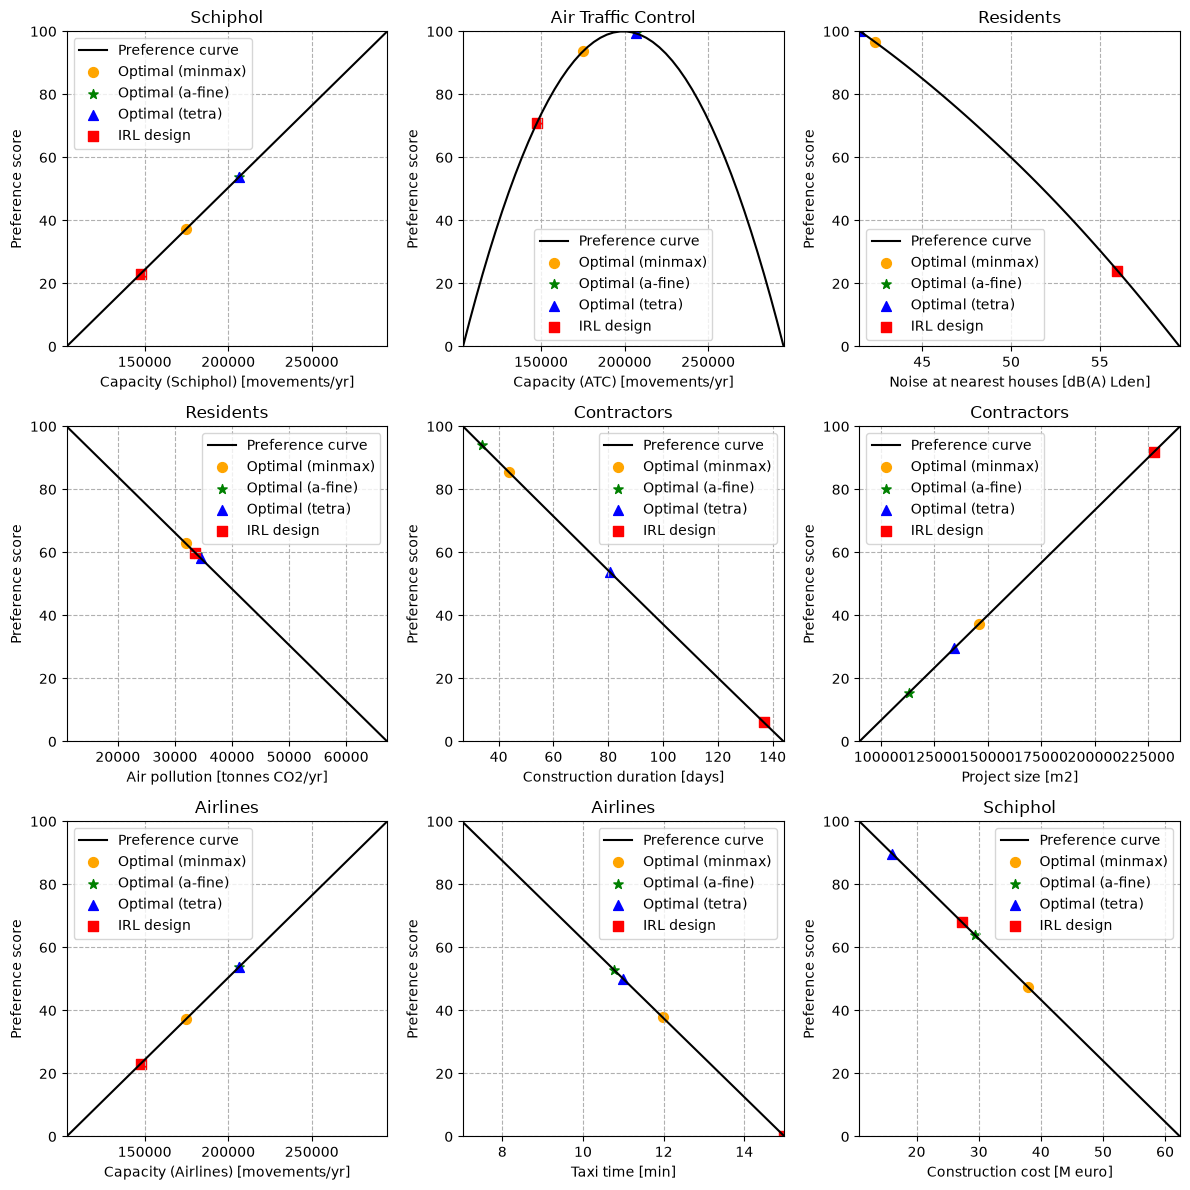

In [ ]:
# We run the optimization with two paradigms
paradigm = ['minmax', 'a-fine', 'tetra']  # 'minmax' or 'a-fine' or 'tetra'
markers  = ['o', '*', '^']
colours  = ['orange', 'green', 'blue']

# Define the figure and axes before the loop
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# Plot underlying preference curves using a loop
for ax, o_vals, p_vals, (_, name, unit, stakeholder) in zip(axes.flat, obj_vals_list, pref_vals_list, objectives): 
    ax.plot(o_vals, p_vals, color='black', label='Preference curve')
    ax.set_xlim(min(o_vals), max(o_vals))
    ax.set_ylim(0, 100)
    ax.set_title(stakeholder)
    ax.set_xlabel(f'{name} [{unit}]')
    ax.set_ylabel('Preference score')
    ax.grid(linestyle='--')

for i in range(len(paradigm)):
    # Dictionary with parameter settings for the GA run with the IMAP solver for test stuff changed values check comments
    options = {
        'n_bits': 8, #8
        'n_iter': 400,
        'n_pop': 500, #500
        'r_cross': 0.8,
        'max_stall': 16, #16
        'aggregation': paradigm[i],  
        'var_type': 'real'
    }

    # Run the GA and print its result
    print(f'\nRun GA with {paradigm[i]}')
    ga = GeneticAlgorithm(objective=objective, constraints=cons, bounds=bounds, options=options)
    _, optimal_design_var, _ = ga.run()

    # print the optimal design variable values
    print(f'Optimal design variable values using {paradigm[i]}:') 
    for opt_var, (xi, name, unit) in zip(optimal_design_var, design_variables):
        print(f'  {xi} : {name:<25} = {opt_var:>10.2f} {unit}') 

    # Print and plot the optimal objective results and stakeholder preferences
    print(f'Optimal objective results and stakeholder preference using {paradigm[i]}:')
    for j, (ax, (obj_func, name, unit, stakeholder)) in enumerate(zip(axes.flat, objectives)):
        obj_value = obj_func(*optimal_design_var) # Calculate resulting objective value
        pref_score = pref_funcs[j](*optimal_design_var) # Calculate resulting preference score
    
        # Print and plot the optimal point on the preference curve
        print(f'  {name:<25} = {obj_value:>15,.2f} {unit:<14} -> {stakeholder:<20} pref: {pref_score:>6.2f}')
        ax.scatter(obj_value, pref_score, color=colours[i], marker=markers[i], s=50,
                   label=f'Optimal ({paradigm[i]})')


# plot the IRL design point if plot_irl is True
if plot_irl:   
    irl_obj_values = [obj_func(*X_irl) for obj_func, _, _, _ in objectives]
    irl_pref_scores = [pref_funcs[j](*X_irl) for j in range(len(objectives))]
    for j, ax in enumerate(axes.flat[:len(objectives)]):
        ax.scatter(irl_obj_values[j], irl_pref_scores[j], color='red', marker='s', s=50, label='IRL design')

for ax in axes.flat[:len(objectives)]:
    ax.legend(fontsize=10)

axes.flat[-1].set_visible(True)  # hide empty 9th subplot

# Adjust the layout 
fig.tight_layout()

# Save figure
# plt.savefig('optimal_results.png')  # Uncomment this line to save the figure as a PNG file

# Display the plot
plt.show()